In [1]:
%reload_ext autoreload
%autoreload 2

In [2]:
# from kret_studies import *
# from kret_studies.notebook import *
# from kret_studies.complex import *

# logger = get_notebook_logger()

In [3]:
from waymo_agent.notebook_imports import *

In [4]:
from waymo_agent import *
from waymo_agent.osmnx import *
from waymo_agent.data_classes import *
from waymo_agent.action_heuristic import *
from waymo_agent.graph_env import *
from waymo_agent.simulation import *
from waymo_agent.action_heuristic.heuristic_simple import PricingAgent, DispatchAgent, RepositionAgent
from kret_sandbox.VIS import dtt

In [5]:
config = EnvConfig()
plt_cfg = PlotConfig()

In [6]:
env = RideShareEnv(config, plt_cfg)
G = env.G
cfg = env.config

Assigned lambda values to nodes. Total lambda: 2.3460 (target: 2.3460)


In [7]:
price_agent = PricingAgent(env.config)
dispatch_agent = DispatchAgent(env)
reposition_agent = RepositionAgent(env)

In [8]:
obs, info = env.reset()

In [9]:
def get_obvs_tuple(env: RideShareEnv):
    veh = env.observation_curr["vehicles"]
    req = env.observation_curr["pending_requests"]
    rides = env.observation_curr["active_rides"]
    return veh, req, rides

In [10]:
veh, req, rides = get_obvs_tuple(env)
veh.shape, req.shape, rides.shape

((24, 6), (50, 21), (24, 18))

In [11]:
action_rnd = env.action_space.sample()
dispatches = pd.DataFrame({"dispatch": action_rnd["dispatch"]})
prices = pd.DataFrame({"prices": action_rnd["prices"]})
reposition = pd.DataFrame(action_rnd["reposition"], columns=["x", "y"])
# action_rnd["dispatch"] = np.full(action_rnd["dispatch"].shape, cfg.no_action_id, dtype=np.int32)
# action_rnd["reposition"] = np.array([[-0.1, -0.1], [0.1, 0.1]], dtype=np.float32)
env.action_space.contains(action_rnd)

True

In [12]:
veh.shape

(24, 6)

## Pre-Step

In [13]:
req_obs = RequestDF(RequestDF.from_obs_numpy(obs["pending_requests"]))
veh_obs = VehicleDF(VehicleDF.from_obs_numpy(obs["vehicles"]))
rides_obs = ActiveRideDF(ActiveRideDF.from_obs_numpy(obs["active_rides"]))
dtt(
    [req_obs, req_obs.f_valid, req_obs.f_awaiting_price, req_obs.f_need_dispatch],
    10,
    titles=["Pending Requests After Step", "f_valid", "f_awaiting_price", "f_need_dispatch"],
)

,pickup_x_norm,pickup_y_norm,dropoff_x_norm,dropoff_y_norm,distance_meters,cust_bias,cust_temperature,est_cost,max_wait_time,wait_time,status
,float64,float64,float64,float64,float64,float64,float64,float64,timedelta64[ns],timedelta64[ns],int64
2,-0.113,-0.061,-0.202,-0.482,3779.082,0.415,1.549,3.779,0 days 00:15:00,0 days,0
6,-1.000,-1.000,-1.000,-1.000,-1.000,-1.000,-1.000,-1.000,0 days 00:15:00,0 days,-10
10,-1.000,-1.000,-1.000,-1.000,-1.000,-1.000,-1.000,-1.000,0 days 00:15:00,0 days,-10
18,-1.000,-1.000,-1.000,-1.000,-1.000,-1.000,-1.000,-1.000,0 days 00:15:00,0 days,-10
21,-1.000,-1.000,-1.000,-1.000,-1.000,-1.000,-1.000,-1.000,0 days 00:15:00,0 days,-10
22,-1.000,-1.000,-1.000,-1.000,-1.000,-1.000,-1.000,-1.000,0 days 00:15:00,0 days,-10
36,-1.000,-1.000,-1.000,-1.000,-1.000,-1.000,-1.000,-1.000,0 days 00:15:00,0 days,-10
40,-1.000,-1.000,-1.000,-1.000,-1.000,-1.000,-1.000,-1.000,0 days 00:15:00,0 days,-10
45,-1.000,-1.000,-1.000,-1.000,-1.000,-1.000,-1.000,-1.000,0 days 00:15:00,0 days,-10


In [14]:
dtt([veh_obs, rides_obs], 10, titles=["Vehicles", "Active Rides"])

,loc_x_norm,loc_y_norm,battery,status
,float32,float32,float32,int64
5,-0.408,-0.671,0.897,0
6,0.433,0.765,0.767,0
7,-0.278,-0.640,0.844,0
8,-0.339,-0.746,0.607,0
9,0.498,0.593,0.925,0
10,-0.473,-0.831,0.875,0
14,-0.213,0.200,0.666,0
18,-0.167,-0.562,0.730,0
19,-0.204,-0.483,0.965,0


In [15]:
prices = price_agent.price(obs)
dispatch_actions = dispatch_agent.dispatch(obs)
reposition_actions = reposition_agent.reposition(obs)

prices_df = pd.DataFrame({"prices": prices})
dispatch_df = pd.DataFrame({"dispatch": dispatch_actions})
reposition_df = pd.DataFrame(reposition_actions, columns=["x", "y"])

action_agent: ActionDict = {
    "prices": prices,
    "dispatch": dispatch_actions,
    "reposition": reposition_actions,
}

In [16]:
dtt([prices_df, dispatch_df, reposition_df], titles=["Prices", "Dispatch", "Reposition"])

,prices
,float32
1,1.348
15,0.000
30,0.000
37,0.000
40,0.000
,dispatch
,int64
1,-1
15,-1


In [17]:
dtt([veh, rides], n=12, how="head", titles=["Vehicles", "Rides"])

,vehicle_id,loc_x_norm,loc_y_norm,battery,status,ride_id
,int64,float32,float32,float32,int64,int64
0,0,-0.520,-0.822,0.987,0,-1
1,1,0.556,0.437,0.623,0,-1
2,2,-0.049,0.517,0.711,0,-1
3,3,0.671,0.554,0.915,0,-1
4,4,0.032,-0.656,0.826,0,-1
5,5,-0.408,-0.671,0.897,0,-1
6,6,0.433,0.765,0.767,0,-1
7,7,-0.278,-0.640,0.844,0,-1
8,8,-0.339,-0.746,0.607,0,-1


In [18]:
dtt([req], titles=["Valid Requests"])

,request_id,request_dt,cust_id,cust_bias,cust_temperature,est_cost,price,max_wait_time,wait_time,status,pickup_node_id,pickup_x_norm,pickup_y_norm,dropoff_node_id,dropoff_x_norm,dropoff_y_norm,route_nodes,curr_start_node,curr_end_node,route_dist_on_edge,distance_meters
,int64,datetime64[ns],int64,float64,float64,float64,float64,timedelta64[ns],timedelta64[ns],int64,int64,float64,float64,int64,float64,float64,object,int64,int64,float64,float64
1,5,2025-01-04 02:59:35.886839,33990,-1.797,1.911,1.319,NaN,0 days 00:15:00,0 days,0,42450820,0.054,-0.617,42423307,-0.029,-0.692,"[42450820, 42423296, 370888100, 42438531, 588455698, 42423307]",42450820,42423296,0.0,1319.273
8,-1,NaT,-1,-1.000,-1.000,-1.000,-1.0,0 days 00:15:00,0 days,-10,-1,-1.000,-1.000,-1,-1.000,-1.000,[],-1,-1,-1.0,-1.000
33,-1,NaT,-1,-1.000,-1.000,-1.000,-1.0,0 days 00:15:00,0 days,-10,-1,-1.000,-1.000,-1,-1.000,-1.000,[],-1,-1,-1.0,-1.000
41,-1,NaT,-1,-1.000,-1.000,-1.000,-1.0,0 days 00:15:00,0 days,-10,-1,-1.000,-1.000,-1,-1.000,-1.000,[],-1,-1,-1.0,-1.000
49,-1,NaT,-1,-1.000,-1.000,-1.000,-1.0,0 days 00:15:00,0 days,-10,-1,-1.000,-1.000,-1,-1.000,-1.000,[],-1,-1,-1.0,-1.000


# Take Step

In [19]:
env.config.max_new_requests_per_step = 2

In [20]:
obs, reward, trunc, term, info = env.step(action_agent)
req_obs = RequestDF(RequestDF.from_obs_numpy(obs["pending_requests"]))
req_obs.f_awaiting_price.sum()

np.int64(2)

In [21]:
req_obs = RequestDF(RequestDF.from_obs_numpy(obs["pending_requests"]))
veh_obs = VehicleDF(VehicleDF.from_obs_numpy(obs["vehicles"]))
rides_obs = ActiveRideDF(ActiveRideDF.from_obs_numpy(obs["active_rides"]))
dtt(
    [req_obs, req_obs.f_valid, req_obs.f_awaiting_price, req_obs.f_need_dispatch],
    10,
    titles=["Pending Requests After Step", "f_valid", "f_awaiting_price", "f_need_dispatch"],
)

,pickup_x_norm,pickup_y_norm,dropoff_x_norm,dropoff_y_norm,distance_meters,cust_bias,cust_temperature,est_cost,max_wait_time,wait_time,status
,float64,float64,float64,float64,float64,float64,float64,float64,timedelta64[ns],timedelta64[ns],int64
6,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,0 days 00:15:00,NaT,-10
8,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,0 days 00:15:00,NaT,-10
11,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,0 days 00:15:00,NaT,-10
20,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,0 days 00:15:00,NaT,-10
25,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,0 days 00:15:00,NaT,-10
30,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,0 days 00:15:00,NaT,-10
32,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,0 days 00:15:00,NaT,-10
40,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,0 days 00:15:00,NaT,-10
47,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,0 days 00:15:00,NaT,-10


In [22]:
dtt(
    [env._dispatch_debug, env.breadcrumbs, env.DiscardedRequests],
    n=10,
    titles=["Dispatch Debug", "Breadcrumbs", "Discarded Requests"],
)

,vehicle_id,penalty_multiple_dispatch_assignment,penalty_assign_to_unavailable_vehicle,distance_penalty_xy_normed,is_newly_assigned
,int64,float64,float64,float64,bool
6,-1,0.0,0.0,0.0,False
7,-1,0.0,0.0,0.0,False
9,-1,0.0,0.0,0.0,False
12,-1,0.0,0.0,0.0,False
18,-1,0.0,0.0,0.0,False
35,-1,0.0,0.0,0.0,False
37,-1,0.0,0.0,0.0,False
38,-1,0.0,0.0,0.0,False
43,-1,0.0,0.0,0.0,False


In [23]:
veh, req, rides = get_obvs_tuple(env)

In [24]:
dtt([req], 10, titles=["Valid Requests"])

,request_id,request_dt,cust_id,cust_bias,cust_temperature,est_cost,price,max_wait_time,wait_time,status,pickup_node_id,pickup_x_norm,pickup_y_norm,dropoff_node_id,dropoff_x_norm,dropoff_y_norm,route_nodes,curr_start_node,curr_end_node,route_dist_on_edge,distance_meters
,int64,datetime64[ns],int64,float64,float64,float64,float64,timedelta64[ns],timedelta64[ns],int64,int64,float64,float64,int64,float64,float64,object,int64,int64,float64,float64
0,8,2025-01-04 03:00:35.886839,24584,-0.378,1.532,10.974,NaN,0 days 00:15:00,0 days 00:00:00,0,6223571524,0.263,0.850,42437612,-0.204,-0.481,"[6223571524, 6223571523, 42428782, 42421745, 42428714, 42428711, 42428674, 42428653, 42428634, 9177424867, 42428595, 9915469771, 42428588, 42428575, 1825841655, 1825841704, 42435714, 42435707, 42435705, 42435684, 42432589, 42435675, 42432700, 42435663, 42435650, 42435646, 42435644, 42435624, 42432214, 42430828, 42430237, 4321748237, 4202908174, 42428447, 42445511, 42437612]",6223571524,6223571523,0.0,10974.463
3,4,2025-01-04 02:59:35.886839,43815,0.415,1.549,3.779,3.863,0 days 00:15:00,0 days 00:01:00,1,42430311,-0.113,-0.061,1773082410,-0.202,-0.482,"[42430311, 42430304, 42437644, 42445365, 561042190, 4597668041, 42448693, 42446925, 42448701, 42440729, 1773084402, 1773082410]",42430311,42430304,0.0,3779.082
9,-1,NaT,-1,-1.000,-1.000,-1.000,-1.000,0 days 00:15:00,NaT,-10,-1,-1.000,-1.000,-1,-1.000,-1.000,[],-1,-1,-1.0,-1.000
20,-1,NaT,-1,-1.000,-1.000,-1.000,-1.000,0 days 00:15:00,NaT,-10,-1,-1.000,-1.000,-1,-1.000,-1.000,[],-1,-1,-1.0,-1.000
26,-1,NaT,-1,-1.000,-1.000,-1.000,-1.000,0 days 00:15:00,NaT,-10,-1,-1.000,-1.000,-1,-1.000,-1.000,[],-1,-1,-1.0,-1.000
34,-1,NaT,-1,-1.000,-1.000,-1.000,-1.000,0 days 00:15:00,NaT,-10,-1,-1.000,-1.000,-1,-1.000,-1.000,[],-1,-1,-1.0,-1.000
41,-1,NaT,-1,-1.000,-1.000,-1.000,-1.000,0 days 00:15:00,NaT,-10,-1,-1.000,-1.000,-1,-1.000,-1.000,[],-1,-1,-1.0,-1.000
44,-1,NaT,-1,-1.000,-1.000,-1.000,-1.000,0 days 00:15:00,NaT,-10,-1,-1.000,-1.000,-1,-1.000,-1.000,[],-1,-1,-1.0,-1.000
45,-1,NaT,-1,-1.000,-1.000,-1.000,-1.000,0 days 00:15:00,NaT,-10,-1,-1.000,-1.000,-1,-1.000,-1.000,[],-1,-1,-1.0,-1.000


In [25]:
dtt([veh, rides])

vehicle_id 
 loc_x_norm 
 loc_y_norm 
 battery 
 status 
 ride_id 
 
 
 
 int64 
 float32 
 float32 
 float32 
 int64 
 int64 
 
 
 
 
 1 
 1 
 0.474 
 0.343 
 0.623 
 0 
 -1 
 
 
 3 
 3 
 -0.246 
 -0.005 
 0.915 
 0 
 -1 
 
 
 9 
 9 
 -0.079 
 -0.633 
 0.925 
 0 
 -1 
 
 
 14 
 14 
 -0.101 
 0.114 
 0.666 
 0 
 -1 
 
 
 16 
 16 
 -0.452 
 -0.185 
 0.649 
 0 
 -1 
 
 
 
 
 
 
 ride_id 
 vehicle_id 
 pickup_node 
 pickup_x_norm 
 pickup_y_norm 
 dropoff_node 
 dropoff_x_norm 
 dropoff_y_norm 
 price 
 est_cost 
 total_trip_distance_meters 
 trip_distance_remaining_meters 
 pickup_distance_remaining_meters 
 route_nodes 
 curr_start_node 
 curr_end_node 
 route_dist_on_edge 
 is_complete 
 
 
 
 int64 
 int64 
 int64 
 float32 
 float32 
 int64 
 float32 
 float32 
 float32 
 float32 
 float32 
 float32 
 float32 
 object 
 int64 
 int64 
 float32 
 bool 
 
 
 
 
 1 
 -1 
 1 
 -1 
 -1.0 
 -1.0 
 -1 
 -1.0 
 -1.0 
 -1.0 
 -1.0 
 -1.0 
 -1.0 
 -1.0 
 [] 
 -1 
 -1 
 -1.0 
 False 
 
 
 3 
 -1 
 3 
 -1 
 -1.0 
 -1.0 
 -1 
 -1.0 
 -1.0 
 -1.0 
 -1.0 
 -1.0 
 -1.0 
 -1.0 
 [] 
 -1 
 -1 
 -1.0 
 False 
 
 
 9 
 -1 
 9 
 -1 
 -1.0 
 -1.0 
 -1 
 -1.0 
 -1.0 
 -1.0 
 -1.0 
 -1.0 
 -1.0 
 -1.0 
 [] 
 -1 
 -1 
 -1.0 
 False 
 
 
 14 
 -1 
 14 
 -1 
 -1.0 
 -1.0 
 -1 
 -1.0 
 -1.0 
 -1.0 
 -1.0 
 -1.0 
 -1.0 
 -1.0 
 [] 
 -1 
 -1 
 -1.0 
 False 
 
 
 16 
 -1 
 16 
 -1 
 -1.0 
 -1.0 
 -1 
 -1.0 
 -1.0 
 -1.0 
 -1.0 
 -1.0 
 -1.0 
 -1.0 
 [] 
 -1 
 -1 
 -1.0 
 False

In [26]:
env.breadcrumbs["rewards"].sum()

np.float64(0.0)

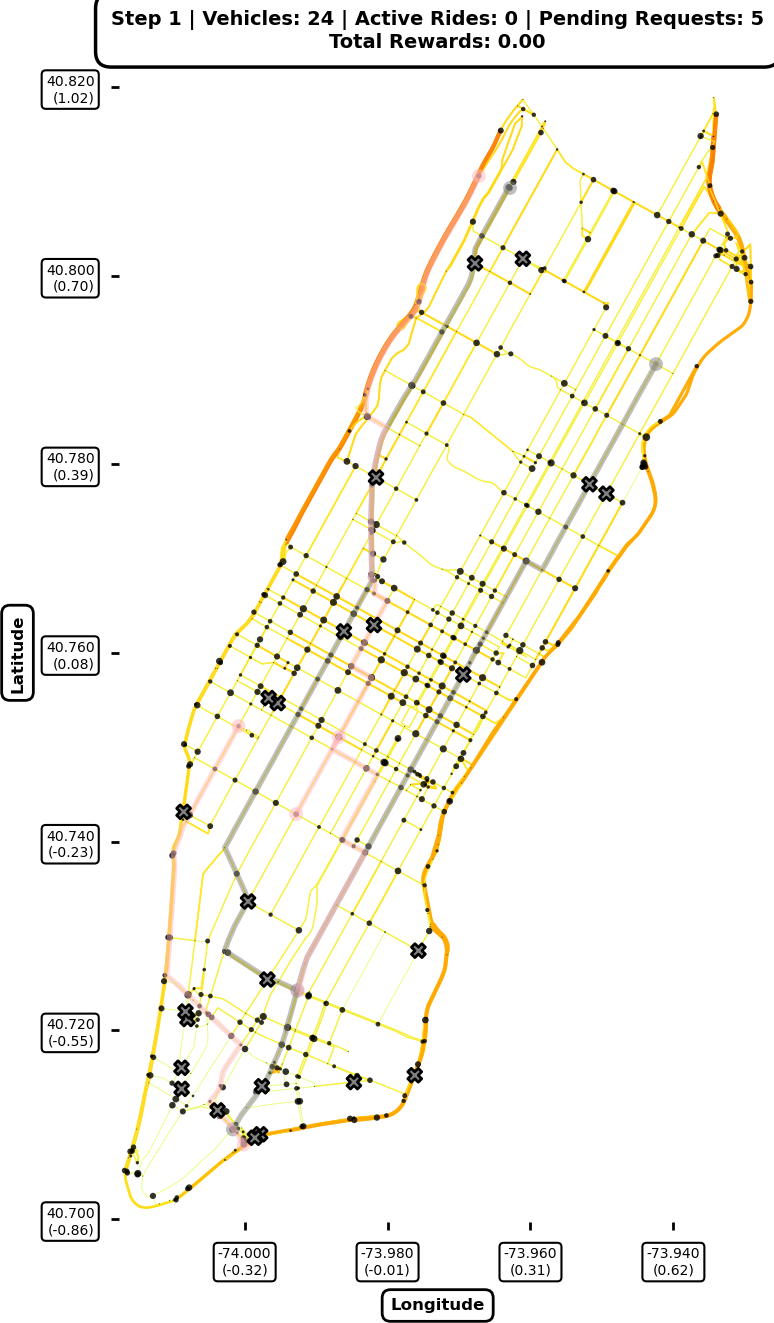

In [27]:
fig, ax = env.render()
fig